In [1]:
#https://realpython.com/nltk-nlp-python/#lemmatizing

**Table of Contents:**

Getting Started With Python’s NLTK

Tokenizing

Filtering Stop Words

Stemming

Tagging Parts of Speech

Lemmatizing

Chunking

Chinking

Using Named Entity Recognition (NER)

Getting Text to Analyze

Using a Concordance

Making a Dispersion Plot

Making a Frequency Distribution

Finding Collocations

Conclusion

In [12]:
#! python -m pip install nltk==3.5

In [10]:
#! python -m pip install matplotlib numpy

In [4]:
from nltk.tokenize import sent_tokenize, word_tokenize

In [6]:
example_string = """
Muad'Dib learned rapidly because his first training was in how to learn.
And the first lesson of all was the basic trust that he could learn.
It's shocking to find how many people do not believe they can learn,
and how many more believe learning to be difficult."""

In [8]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wayne\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [14]:
sent_tokenize(example_string)

["\nMuad'Dib learned rapidly because his first training was in how to learn.",
 'And the first lesson of all was the basic trust that he could learn.',
 "It's shocking to find how many people do not believe they can learn,\nand how many more believe learning to be difficult."]

In [16]:
word_tokenize(example_string)

["Muad'Dib",
 'learned',
 'rapidly',
 'because',
 'his',
 'first',
 'training',
 'was',
 'in',
 'how',
 'to',
 'learn',
 '.',
 'And',
 'the',
 'first',
 'lesson',
 'of',
 'all',
 'was',
 'the',
 'basic',
 'trust',
 'that',
 'he',
 'could',
 'learn',
 '.',
 'It',
 "'s",
 'shocking',
 'to',
 'find',
 'how',
 'many',
 'people',
 'do',
 'not',
 'believe',
 'they',
 'can',
 'learn',
 ',',
 'and',
 'how',
 'many',
 'more',
 'believe',
 'learning',
 'to',
 'be',
 'difficult',
 '.']

In [18]:
nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wayne\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
worf_quoate = 'Sir, I protest. I am not a merry man!'

In [22]:
words_in_quote  = word_tokenize(worf_quoate)
words_in_quote

['Sir', ',', 'I', 'protest', '.', 'I', 'am', 'not', 'a', 'merry', 'man', '!']

In [24]:
stop_words = set(stopwords.words("english"))

In [26]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [28]:
filtered_list = []

for word in words_in_quote:
  if word.casefold() not in stop_words:
    filtered_list.append(word)

filtered_list

['Sir', ',', 'protest', '.', 'merry', 'man', '!']

In [30]:
filtered_list = [word for word in words_in_quote if word.casefold() not in stop_words]
filtered_list

['Sir', ',', 'protest', '.', 'merry', 'man', '!']

# Stemming

Stemming is a text processing task in which you reduce words to their root, which is the core part of a word. For example, the words “helping” and “helper” share the root “help.” Stemming allows you to zero in on the basic meaning of a word rather than all the details of how it’s being used

In [32]:
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stemmer = PorterStemmer()

In [34]:
string_for_stemming = """
The crew of the USS Discovery discovered many discoveries.
Discovering is what explorers do."""

In [36]:
words = word_tokenize(string_for_stemming)
words

['The',
 'crew',
 'of',
 'the',
 'USS',
 'Discovery',
 'discovered',
 'many',
 'discoveries',
 '.',
 'Discovering',
 'is',
 'what',
 'explorers',
 'do',
 '.']

In [38]:
stemmed_words = [stemmer.stem(word) for word in words]
stemmed_words

['the',
 'crew',
 'of',
 'the',
 'uss',
 'discoveri',
 'discov',
 'mani',
 'discoveri',
 '.',
 'discov',
 'is',
 'what',
 'explor',
 'do',
 '.']

#Understemming and overstemming are two ways stemming can go wrong:

Understemming happens when two related words should be reduced to the same stem but aren’t. This is a false negative.
Overstemming happens when two unrelated words are reduced to the same stem even though they shouldn’t be. This is a false positive.


#Tagging Parts of Speech
Part of speech is a grammatical term that deals with the roles words play when you use them together in sentences. Tagging parts of speech, or POS tagging, is the task of labeling the words in your text according to their part of speech.

In English, there are eight parts of speech:

Part of speech	Role	Examples
Noun	Is a person, place, or thing	mountain, bagel, Poland
Pronoun	Replaces a noun	you, she, we
Adjective	Gives information about what a noun is like	efficient, windy, colorful
Verb	Is an action or a state of being	learn, is, go
Adverb	Gives information about a verb, an adjective, or another adverb	efficiently, always, very
Preposition	Gives information about how a noun or pronoun is connected to another word	from, about, at
Conjunction	Connects two other words or phrases	so, because, and
Interjection	Is an exclamation	yay, ow, wow
Some sources also include the category articles (like “a” or “the”) in the list of parts of speech, but other sources consider them to be adjectives. NLTK uses the word determiner to refer to articles.

In [40]:
from nltk.tokenize import word_tokenize

In [42]:
sagan_quote = """
If you wish to make an apple pie from scratch,
you must first invent the universe."""


words_in_sagan_quote = word_tokenize(sagan_quote)
words_in_sagan_quote

['If',
 'you',
 'wish',
 'to',
 'make',
 'an',
 'apple',
 'pie',
 'from',
 'scratch',
 ',',
 'you',
 'must',
 'first',
 'invent',
 'the',
 'universe',
 '.']

In [15]:
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.pos_tag(words_in_sagan_quote)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


[('If', 'IN'),
 ('you', 'PRP'),
 ('wish', 'VBP'),
 ('to', 'TO'),
 ('make', 'VB'),
 ('an', 'DT'),
 ('apple', 'NN'),
 ('pie', 'NN'),
 ('from', 'IN'),
 ('scratch', 'NN'),
 (',', ','),
 ('you', 'PRP'),
 ('must', 'MD'),
 ('first', 'VB'),
 ('invent', 'VB'),
 ('the', 'DT'),
 ('universe', 'NN'),
 ('.', '.')]

In [46]:
import nltk
nltk.download('tagsets_json')


[nltk_data] Downloading package tagsets_json to
[nltk_data]     C:\Users\wayne\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping help\tagsets_json.zip.


True

In [48]:
nltk.help.upenn_tagset()


$: dollar
    $ -$ --$ A$ C$ HK$ M$ NZ$ S$ U.S.$ US$
'': closing quotation mark
    ' ''
(: opening parenthesis
    ( [ {
): closing parenthesis
    ) ] }
,: comma
    ,
--: dash
    --
.: sentence terminator
    . ! ?
:: colon or ellipsis
    : ; ...
CC: conjunction, coordinating
    & 'n and both but either et for less minus neither nor or plus so
    therefore times v. versus vs. whether yet
CD: numeral, cardinal
    mid-1890 nine-thirty forty-two one-tenth ten million 0.5 one forty-
    seven 1987 twenty '79 zero two 78-degrees eighty-four IX '60s .025
    fifteen 271,124 dozen quintillion DM2,000 ...
DT: determiner
    all an another any both del each either every half la many much nary
    neither no some such that the them these this those
EX: existential there
    there
FW: foreign word
    gemeinschaft hund ich jeux habeas Haementeria Herr K'ang-si vous
    lutihaw alai je jour objets salutaris fille quibusdam pas trop Monte
    terram fiche oui corporis ...
IN: preposition or

In [50]:
jabberwocky_excerpt = """
'Twas brillig, and the slithy toves did gyre and gimble in the wabe:
all mimsy were the borogoves, and the mome raths outgrabe."""


words_in_excerpt = word_tokenize(jabberwocky_excerpt)
nltk.pos_tag(words_in_excerpt)

[("'T", 'NN'),
 ('was', 'VBD'),
 ('brillig', 'VBN'),
 (',', ','),
 ('and', 'CC'),
 ('the', 'DT'),
 ('slithy', 'JJ'),
 ('toves', 'NNS'),
 ('did', 'VBD'),
 ('gyre', 'NN'),
 ('and', 'CC'),
 ('gimble', 'JJ'),
 ('in', 'IN'),
 ('the', 'DT'),
 ('wabe', 'NN'),
 (':', ':'),
 ('all', 'DT'),
 ('mimsy', 'NNS'),
 ('were', 'VBD'),
 ('the', 'DT'),
 ('borogoves', 'NNS'),
 (',', ','),
 ('and', 'CC'),
 ('the', 'DT'),
 ('mome', 'JJ'),
 ('raths', 'NNS'),
 ('outgrabe', 'RB'),
 ('.', '.')]

# Chunking
While tokenizing allows you to identify words and sentences, chunking allows you to identify phrases.
 A chunk grammar is a combination of rules on how sentences should be chunked. It often uses regular expressions, or regexes.



In [52]:
from nltk.tokenize import word_tokenize

Before you can chunk,
1-  need to make sure that the parts of speech in your text are tagged, so create a string for POS tagging.

In [55]:
lotr_quote = "It's a dangerous business, Frodo, going out your door."
words_in_lotr_quote = word_tokenize(lotr_quote)
words_in_lotr_quote

['It',
 "'s",
 'a',
 'dangerous',
 'business',
 ',',
 'Frodo',
 ',',
 'going',
 'out',
 'your',
 'door',
 '.']

2- tag those words by part of speech

In [57]:
nltk.download("averaged_perceptron_tagger")
lotr_pos_tags = nltk.pos_tag(words_in_lotr_quote)
lotr_pos_tags

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\wayne\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


[('It', 'PRP'),
 ("'s", 'VBZ'),
 ('a', 'DT'),
 ('dangerous', 'JJ'),
 ('business', 'NN'),
 (',', ','),
 ('Frodo', 'NNP'),
 (',', ','),
 ('going', 'VBG'),
 ('out', 'RP'),
 ('your', 'PRP$'),
 ('door', 'NN'),
 ('.', '.')]

# Getting Text to Analyze:

In [59]:
nltk.download('book')
from nltk.book import *

[nltk_data] Downloading collection 'book'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\wayne\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\abc.zip.
[nltk_data]    | Downloading package brown to
[nltk_data]    |     C:\Users\wayne\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\brown.zip.
[nltk_data]    | Downloading package chat80 to
[nltk_data]    |     C:\Users\wayne\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\chat80.zip.
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     C:\Users\wayne\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\cmudict.zip.
[nltk_data]    | Downloading package conll2000 to
[nltk_data]    |     C:\Users\wayne\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\conll2000.zip.
[nltk_data]    | Downloading package conll2002 to
[nltk_data]    |     C:\Users\wayne\AppData\Roaming\nltk_data...
[nltk_data]    |   U

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908


In [60]:
text8.concordance("man")

Displaying 14 of 14 matches:
 to hearing from you all . ABLE young man seeks , sexy older women . Phone for 
ble relationship . GENUINE ATTRACTIVE MAN 40 y . o ., no ties , secure , 5 ft .
ship , and quality times . VIETNAMESE MAN Single , never married , financially 
ip . WELL DRESSED emotionally healthy man 37 like to meet full figured woman fo
 nth subs LIKE TO BE MISTRESS of YOUR MAN like to be treated well . Bold DTE no
eeks lady in similar position MARRIED MAN 50 , attrac . fit , seeks lady 40 - 5
eks nice girl 25 - 30 serious rship . Man 46 attractive fit , assertive , and k
 40 - 50 sought by Aussie mid 40s b / man f / ship r / ship LOVE to meet widowe
discreet times . Sth E Subs . MARRIED MAN 42yo 6ft , fit , seeks Lady for discr
woman , seeks professional , employed man , with interests in theatre , dining 
 tall and of large build seeks a good man . I am a nonsmoker , social drinker ,
lead to relationship . SEEKING HONEST MAN I am 41 y . o ., 5 ft . 4 , med . bui
 quiet time

In [61]:
text8.concordance("woman")

Displaying 11 of 11 matches:
at home . Seeking an honest , caring woman , slim or med . build , who enjoys t
thy man 37 like to meet full figured woman for relationship . 48 slim , shy , S
rry . MALE 58 years old . Is there a Woman who would like to spend 1 weekend a 
 other interests . Seeking Christian Woman for fship , view to rship . SWM 45 D
ALE 60 - burly beared seeks intimate woman for outings n / s s / d F / ston / P
ington . SCORPIO 47 seeks passionate woman for discreet intimate encounters SEX
le dad . 42 , East sub . 5 " 9 seeks woman 30 + for f / ship relationship TALL 
personal trainer looking for married woman age open for fun MARRIED Dark guy 37
rinker , seeking slim - medium build woman who is happy in life , age open . AC
. O . TERTIARY Educated professional woman , seeks professional , employed man 
 real romantic , age 50 - 65 y . o . WOMAN OF SUBSTANCE 56 , 59 kg ., 50 , fit 


# Making a Disppersion Plot

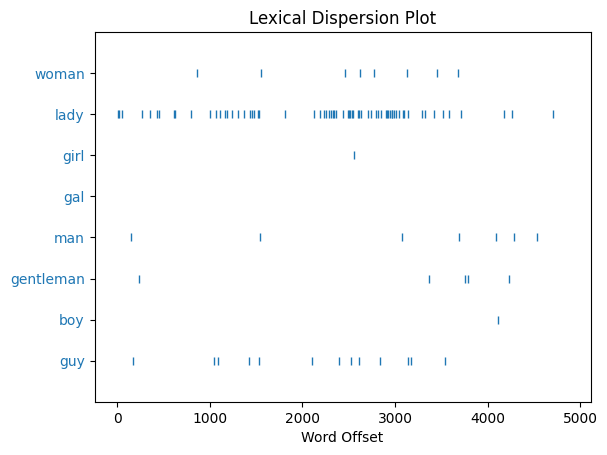

In [65]:
text8.dispersion_plot(
     ["woman", "lady", "girl", "gal", "man", "gentleman", "boy", "guy"]
    )

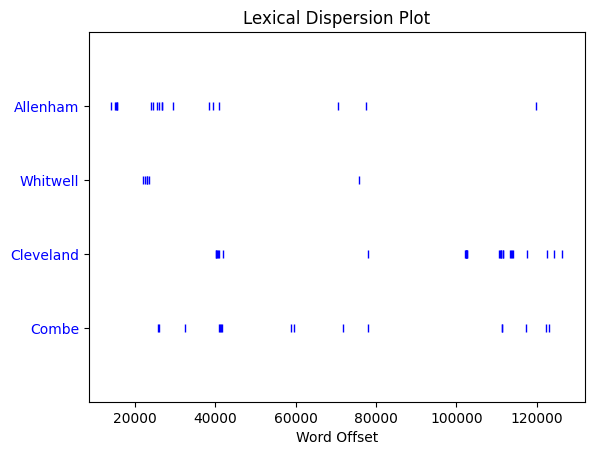

In [32]:
text2.dispersion_plot(["Allenham", "Whitwell", "Cleveland", "Combe"])

# Making a Frequency Distribution

With a frequency distribution, you can check which words show up most frequently in your text.

In [67]:
from nltk import FreqDist



FreqDist is a subclass of collections.Counter. Here’s how to create a frequency distribution of the entire corpus of personals ads:

In [70]:
frequency_distribution = FreqDist(text8)
print(frequency_distribution)

<FreqDist with 1108 samples and 4867 outcomes>


In [72]:
frequency_distribution.most_common(20)

[(',', 539),
 ('.', 353),
 ('/', 110),
 ('for', 99),
 ('and', 74),
 ('to', 74),
 ('lady', 68),
 ('-', 66),
 ('seeks', 60),
 ('a', 52),
 ('with', 44),
 ('S', 36),
 ('ship', 33),
 ('&', 30),
 ('relationship', 29),
 ('fun', 28),
 ('in', 27),
 ('slim', 27),
 ('build', 27),
 ('o', 26)]

You have a lot of stop words in your frequency distribution, but you can remove them just as you did earlier. Create a list of all of the words in text8 that aren’t stop words:

In [75]:
meaning_ful_words = [
    word for word in text8 if word.casefold() not in stop_words
]

frequency_distribution = FreqDist(meaning_ful_words)
frequency_distribution.most_common(20)

[(',', 539),
 ('.', 353),
 ('/', 110),
 ('lady', 68),
 ('-', 66),
 ('seeks', 60),
 ('ship', 33),
 ('&', 30),
 ('relationship', 29),
 ('fun', 28),
 ('slim', 27),
 ('build', 27),
 ('smoker', 23),
 ('50', 23),
 ('non', 22),
 ('movies', 22),
 ('good', 21),
 ('honest', 20),
 ('dining', 19),
 ('rship', 18)]

<Axes: xlabel='Samples', ylabel='Cumulative Counts'>

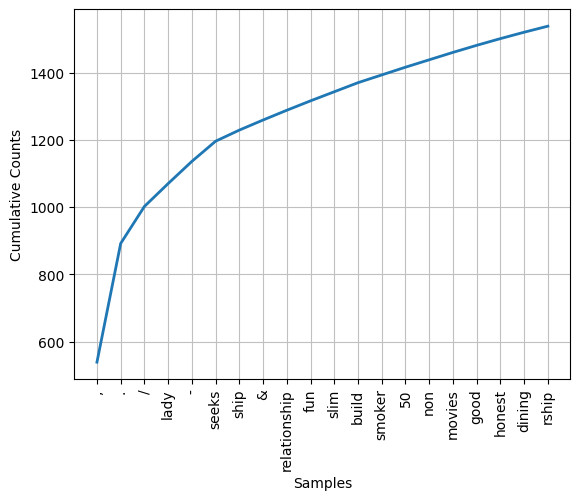

In [77]:
frequency_distribution.plot(20, cumulative=20)

# Finding collections:

A collocation is a sequence of words that shows up often.

Here are some examples of collocations that use the word “tree”:

Syntax tree

Family tree

Decision tree

To see pairs of words that come up often in your corpus, you need to call .

collocations() on it:

In [80]:
text8.collocations()

would like; medium build; social drinker; quiet nights; non smoker;
long term; age open; Would like; easy going; financially secure; fun
times; similar interests; Age open; weekends away; poss rship; well
presented; never married; single mum; permanent relationship; slim
build


In [82]:
 #Lemmitized

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in text8]
lemmatized_words

['25',
 'SEXY',
 'MALE',
 ',',
 'seek',
 'attrac',
 'older',
 'single',
 'lady',
 ',',
 'for',
 'discreet',
 'encounter',
 '.',
 '35YO',
 'Security',
 'Guard',
 ',',
 'seeking',
 'lady',
 'in',
 'uniform',
 'for',
 'fun',
 'time',
 '.',
 '40',
 'yo',
 'SINGLE',
 'DAD',
 ',',
 'sincere',
 'friendly',
 'DTE',
 'seek',
 'r',
 '/',
 'ship',
 'with',
 'fem',
 'age',
 'open',
 'S',
 '/',
 'E',
 '44yo',
 'tall',
 'seek',
 'working',
 'single',
 'mum',
 'or',
 'lady',
 'below',
 '45',
 'fship',
 'rship',
 '.',
 'Nat',
 'Open',
 '6',
 '.',
 '2',
 '35',
 'yr',
 'old',
 'OUTGOING',
 'M',
 'seek',
 'fem',
 '28',
 '-',
 '35',
 'for',
 'o',
 '/',
 'door',
 'sport',
 '-',
 'w',
 '/',
 'e',
 'away',
 'A',
 'professional',
 'business',
 'male',
 ',',
 'late',
 '40',
 ',',
 '6',
 'foot',
 'tall',
 ',',
 'slim',
 'build',
 ',',
 'well',
 'groomed',
 ',',
 'great',
 'personality',
 ',',
 'home',
 'owner',
 ',',
 'interest',
 'include',
 'the',
 'art',
 'travel',
 'and',
 'all',
 'thing',
 'good',
 ',',
 '

In [83]:
new_text = nltk.Text(lemmatized_words)
print(new_text)

<Text: 25 SEXY MALE , seek attrac older single...>
